In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import os
import pathlib
import mne
from scipy.stats import sem
import seaborn as sns
from scipy.stats import t
from scipy.ndimage import gaussian_filter1d
from scipy.signal import convolve
from scipy.stats import linregress
from joblib import Parallel, delayed
import string

In [2]:
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

# Define color palettes
colors0 = sns.color_palette("magma", n_colors=6)
colors1 = sns.color_palette("mako_r", n_colors=10)
pastel = sns.color_palette("Pastel1", n_colors=6)
adapt1 = sns.color_palette("Set1", n_colors=9)
adapt2 = sns.color_palette("Accent", n_colors=8)
colors4 = sns.color_palette("magma_r", n_colors=4)
colors5 = sns.color_palette("mako_r", n_colors=4)

colors2 = [pastel[0], pastel[3], adapt2[5]]
colors3 = [pastel[1], pastel[2], colors5[2]]
colors_implicit = [pastel[0], adapt2[5], pastel[3]]  # Baseline, Washout, Adaptation
colors_explicit = [pastel[1], colors5[2], pastel[2]]  # Baseline, Washout, Adaptation
colorbl = [adapt1[4], colors1[2]]

In [3]:
behav_df = pd.read_csv('./data/derivatives/behav_df_cleaned_new.csv')
behav_df = behav_df[behav_df['reach_vis_abs_err']<=60].reset_index(drop=True)

burst_df = pd.read_csv('./data/derivatives/burst_features.csv')
lookup_df = behav_df[["coh_cat", "perturb_cat", "trial", "block", "subject"]]
# Merge the two DataFrames based on the specified columns
df_burst_behav = burst_df.merge(lookup_df, on=["trial", "block", "subject"], how='left')


In [4]:
vis_epoch_lims=(-1.0, 2.0)
mot_epoch_lims=(-1.0, 1.5)
vis_plot_lims=(-0.5, 1.6)
mot_plot_lims=(-0.75, 1.25)
n_q = 4

In [5]:
def smooth_burst_rate(burst_rate, sigma):
    """Apply Gaussian smoothing with edge-padding to reduce edge artifacts."""
    size = int(6 * sigma) + 1
    x = np.linspace(-3, 3, size)
    kernel = np.exp(-0.5 * x**2)
    kernel /= kernel.sum()
    smoothed = np.convolve(burst_rate, kernel, mode='same')
    return smoothed


def process_trial(args):
    subject, block, trial, trial_df, behav_row, time_range, time_bin, smooth_sigma = args
    binned_counts = np.array([
        np.sum((trial_df['peak_time'] >= t) & (trial_df['peak_time'] < t + time_bin))
        for t in time_range
    ])
    burst_rate = smooth_burst_rate(binned_counts / time_bin, smooth_sigma)
    entry = behav_row.to_dict()
    entry.update({
        'meg_signal': burst_rate,
        'subject': subject,
        'block': block,
        'trial': trial
    })
    return entry


def make_burst_rate_df(PC_to_analyze, df_burst_behav, behav_df, time_bin=0.025, smooth_sigma=1.5, epoch_lims=(-1.0, 1.5), n_jobs=-1):
    time_range = np.arange(epoch_lims[0], epoch_lims[1], time_bin)
    step = 100 / n_q
    q_bins = np.percentile(df_burst_behav[PC_to_analyze], np.arange(0, 100 + step, step))
    q_dfs = []

    for q in range(n_q):
        df_subset = df_burst_behav[
            (df_burst_behav[PC_to_analyze] >= q_bins[q]) &
            (df_burst_behav[PC_to_analyze] < q_bins[q + 1])
        ]
    
        behav_lookup = behav_df.set_index(['subject', 'block', 'trial'])
        grouped = df_subset.groupby(['subject', 'block', 'trial'])
        task_args = []
    
        for (subject, block, trial), group in grouped:
            key = (subject, block, trial)
            if key not in behav_lookup.index:
                continue
            behav_row = behav_lookup.loc[key]
            task_args.append((subject, block, trial, group, behav_row, time_range, time_bin, smooth_sigma))
    
        results = Parallel(n_jobs=n_jobs, prefer='processes', batch_size='auto')(
            delayed(process_trial)(args) for args in task_args
        )

        df = pd.DataFrame(results)
        # trial_means = df['meg_signal'].apply(np.nanmean)
        # mean_val = np.nanmean(trial_means)
        # std_val = np.nanstd(trial_means)

        # def is_outlier(signal):
        #     return np.abs(np.nanmean(signal) - mean_val) > 2.5 * std_val

        # df = df[~df['meg_signal'].apply(is_outlier)].reset_index(drop=True)
        q_dfs.append(df)

    return q_dfs, time_range


def compute_subject_averages(
    dfs, block_filter, time, visual_dfs, visual_time,
    cohcat=None, plot_lims=(-0.75, 1.25), baseline_lims=(-0.5, -0.25),
    exclude_subjects=None, return_subject_means=False
):
    plot_mask = (time >= plot_lims[0]) & (time <= plot_lims[1])
    baseline_mask = (visual_time >= baseline_lims[0]) & (visual_time <= baseline_lims[1])
    time_plot = time[plot_mask]
    q_results = []
    all_subject_means = []

    for i, df in enumerate(dfs):
        result = {}
        group_subject_means = {}

        filtered_df = df[df['block'].isin(block_filter)]
        visual_df = visual_dfs[i][visual_dfs[i]['block'].isin(block_filter)]

        if cohcat:
            filtered_df = filtered_df[filtered_df['coh_cat'] == cohcat]
            visual_df = visual_df[visual_df['coh_cat'] == cohcat]

        for group in filtered_df['group'].unique():
            group_df = filtered_df[filtered_df['group'] == group]
            visual_group_df = visual_df[visual_df['group'] == group]
            subject_arrays = []
            subject_ids = []
            subject_means = {}

            for subject in group_df['subject'].unique():
                if exclude_subjects and subject in exclude_subjects.get(group, []):
                    continue

                subj_data = group_df[group_df['subject'] == subject]
                visual_subj_data = visual_group_df[visual_group_df['subject'] == subject]
                if subj_data.empty or visual_subj_data.empty:
                    continue

                # Match trials
                motor_keys = set(zip(subj_data['block'], subj_data['trial']))
                visual_keys = set(zip(visual_subj_data['block'], visual_subj_data['trial']))
                common_keys = motor_keys & visual_keys

                motor_signals = []
                visual_signals = []
                for blk, trl in common_keys:
                    motor_signal = subj_data[(subj_data['block'] == blk) & (subj_data['trial'] == trl)]['meg_signal']
                    visual_signal = visual_subj_data[(visual_subj_data['block'] == blk) & (visual_subj_data['trial'] == trl)]['meg_signal']
                    if not motor_signal.empty and not visual_signal.empty:
                        motor_signals.append(motor_signal.values[0])
                        visual_signals.append(visual_signal.values[0])

                if motor_signals and visual_signals:
                    motor_avg = np.nanmean(np.stack(motor_signals), axis=0)
                    visual_avg = np.nanmean(np.stack(visual_signals), axis=0)
                    baseline = np.nanmean(visual_avg[baseline_mask])
                    if not np.isnan(baseline):
                        normed = 100 * (motor_avg - baseline) / abs(baseline)
                        if not np.any(np.isnan(normed[plot_mask]) | np.isinf(normed[plot_mask])):
                            subject_arrays.append(normed[plot_mask])
                            subject_ids.append(subject)
                            subject_means[subject] = np.nanmean(normed[plot_mask])

            if subject_arrays:
                subject_arrays = np.array(subject_arrays)
                result[group] = subject_arrays
                group_subject_means[group] = subject_means

        q_results.append(result)
        all_subject_means.append(group_subject_means)

    if return_subject_means:
        # Flatten across PCs
        merged_means = defaultdict(dict)
        for group_dict in all_subject_means:
            for group, subj_dict in group_dict.items():
                merged_means[group].update(subj_dict)
        return q_results, time_plot, dict(merged_means)
    else:
        return q_results, time_plot



In [6]:
def plot_and_cluster_data_between_group(ax, time_range, data, colors, title, xlabel, ylabel, verbose=True):
    data_masked = [d[:, :len(time_range)] for d in data]
    implicit_data, explicit_data = data_masked  

    plotted_max = -np.inf
    for i, (name, d) in enumerate(zip(['Implicit', 'Explicit'], data_masked)):
        mean_curve = np.nanmean(d, axis=0)
        sem_curve = np.nanstd(d, axis=0) / np.sqrt(np.sum(~np.isnan(d), axis=0))
        ax.plot(time_range, mean_curve, label=name, color=colors[i], linewidth=3)
        ax.fill_between(time_range, mean_curve - sem_curve, mean_curve + sem_curve, alpha=0.2, color=colors[i])
        plotted_max = max(plotted_max, np.nanmax(mean_curve + sem_curve))

    # Cluster-based permutation test
    X = [explicit_data, implicit_data]
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        X,
        n_permutations=1000,
        stat_fun=mne.stats.ttest_ind_no_p,  # for independent samples
        tail=0,
        threshold=dict(start=0, step=0.01),
        out_type='mask',
        n_jobs=-1,
        verbose=verbose
    )

    sig_slices = [clusters[i] for i in range(len(cluster_p_values)) if cluster_p_values[i] < 0.05]
    
    if len(sig_slices) > 0:
        print(f"Significant clusters found!")
        y_marker = plotted_max + 0.05 * np.abs(plotted_max)  # Add 5% headroom
        for s in sig_slices:
            sig_indices = np.arange(s.start, s.stop)
            ax.plot(time_range[sig_indices], [y_marker] * len(sig_indices), 'o', color='red', markersize=8, alpha=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='lower left')

def plot_and_cluster_data_blocktype_within_group(ax, time_range, data, colors, title, xlabel, ylabel, verbose=True):
    data_masked = [d[:, :len(time_range)] for d in data]
    condition_names = ["Baseline", "Adaptation", "Washout"]
    plotted_max = -np.inf

    for i, (name, d) in enumerate(zip(condition_names, data_masked)):
        mean_curve = np.nanmean(d, axis=0)
        sem_curve = np.nanstd(d, axis=0) / np.sqrt(np.sum(~np.isnan(d), axis=0))
        ax.plot(time_range, mean_curve, label=name, color=colors[i], linewidth=3)
        ax.fill_between(time_range, mean_curve - sem_curve, mean_curve + sem_curve, alpha=0.2, color=colors[i])
        plotted_max = max(plotted_max, np.nanmax(mean_curve + sem_curve))

    # Cluster-based permutation test
    X = np.stack(data_masked, axis=1)
    factor_levels = [3]
    effects = 'A'
    F_vals, p_vals = mne.stats.f_mway_rm(X, factor_levels, effects=effects)

    X_reshaped = np.concatenate([X[:, i, :] for i in range(X.shape[1])], axis=0)
    condition_inds = np.repeat(np.arange(3), X.shape[0])

    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
        [X_reshaped[condition_inds == i] for i in range(3)],
        n_permutations=10000,
        stat_fun=None,  # default f_oneway
        threshold=None,
        tail=1,
        out_type='mask',
        n_jobs=-1,
        verbose=verbose
    )

    sig_slices = [clusters[i][0] for i in range(len(cluster_p_values)) if cluster_p_values[i] < 0.05]
    
    if sig_slices:
        print("Significant clusters found!")
        y_marker = plotted_max + 0.05 * np.abs(plotted_max)
        for s in sig_slices:
            sig_indices = np.arange(s.start, s.stop)
            ax.plot(time_range[sig_indices], [y_marker] * len(sig_indices), 'o', color='red', markersize=8, alpha=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper right')

def plot_and_cluster_data_coh(ax, time_range, data, colors, title, xlabel, ylabel, verbose=True):
    data_masked = [d[:, :len(time_range)] for d in data]
    coherence_names = ["Zero", "Low", "Medium", "High"]
    coh_levels = np.array([0, 1, 2, 3])
    plotted_max = -np.inf

    for i, (name, d) in enumerate(zip(coherence_names, data_masked)):
        mean_curve = np.nanmean(d, axis=0)
        sem_curve = sem(d, axis=0, nan_policy='omit')
        ax.plot(time_range, mean_curve, label=name, color=colors[i], linewidth=3)
        ax.fill_between(time_range, mean_curve - sem_curve, mean_curve + sem_curve, alpha=0.2, color=colors[i])
        plotted_max = max(plotted_max, np.nanmax(mean_curve + sem_curve))

    # Shape: (n_subjects, n_conditions, n_times)
    X = np.stack(data_masked, axis=1)
    n_subjects, _, n_times = X.shape
    slopes = np.empty((n_subjects, n_times))

    for subj in range(n_subjects):
        for t in range(n_times):
            y = X[subj, :, t]
            slope, _, _, _, _ = linregress(coh_levels, y)
            slopes[subj, t] = slope

    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
        slopes,
        n_permutations=10000,
        tail=0,
        threshold=None,
        out_type='mask',
        n_jobs=-1,
        verbose=verbose
    )

    sig_slices = [clusters[i][0] for i in range(len(cluster_p_values)) if cluster_p_values[i] < 0.05]

    if sig_slices:
        print("Significant clusters found!")
        y_marker = plotted_max + 0.05 * np.abs(plotted_max)
        for s in sig_slices:
            sig_indices = np.arange(s.start, s.stop)
            ax.plot(time_range[sig_indices], [y_marker] * len(sig_indices), 'o', color='red', markersize=8, alpha=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper right')

In [7]:
df_visual = df_burst_behav[df_burst_behav['epoch'] == 'vis']
df_motor = df_burst_behav[df_burst_behav['epoch'] == 'mot']

In [12]:
from collections import defaultdict

def get_union_outliers(subject_means_by_condition, threshold=2.5):
    union_outliers = defaultdict(set)
    for cond, subject_means in subject_means_by_condition.items():
        for group, subj_dict in subject_means.items():
            means = np.array(list(subj_dict.values()))
            ids = list(subj_dict.keys())
            mu = np.nanmean(means)
            sigma = np.nanstd(means)
            outliers = [ids[i] for i, val in enumerate(means) if abs(val - mu) > threshold * sigma]
            union_outliers[group].update(outliers)
    return {group: list(subjs) for group, subjs in union_outliers.items()}

pcs = [f'PC_{i}' for i in range(8, 8)]
#pcs = [f'PC_{i}' for i in range(1, 21)]
phase_blocks = {'baseline': [0], 'adaptation': [1, 2, 3, 4, 5, 6], 'washout': [7]}
cohcats = ['zero', 'low', 'med', 'high']

burst_data = {}
coh_burst_data = {}
time_plots = {}

for pc in pcs:
    print(pc)
    burst_rate_visual_df, vis_time = make_burst_rate_df(pc, df_visual, behav_df, epoch_lims=vis_epoch_lims)
    burst_rate_motor_df, mot_time = make_burst_rate_df(pc, df_motor, behav_df, epoch_lims=mot_epoch_lims)

    burst_data[pc] = {'vis': {}, 'mot': {}}
    coh_burst_data[pc] = {'vis': {}, 'mot': {}}

    # ----- PHASE-WISE ANALYSIS -----
    # VISUAL: detect outliers across phases
    # vis_phase_subject_means = {}
    # for phase in phase_blocks:
    #     _, _, subject_means = compute_subject_averages(
    #         burst_rate_visual_df, phase_blocks[phase], vis_time, burst_rate_visual_df, vis_time,
    #         plot_lims=vis_plot_lims, return_subject_means=True
    #     )
    #     vis_phase_subject_means[phase] = subject_means
    # vis_phase_outliers = get_union_outliers(vis_phase_subject_means)

    for phase in phase_blocks:
        burst_data[pc]['vis'][phase], vis_plot_time = compute_subject_averages(
            burst_rate_visual_df, phase_blocks[phase], vis_time, burst_rate_visual_df, vis_time,
            plot_lims=vis_plot_lims#, exclude_subjects=vis_phase_outliers
        )

    # MOTOR: detect outliers across phases
    # mot_phase_subject_means = {}
    # for phase in phase_blocks:
    #     _, _, subject_means = compute_subject_averages(
    #         burst_rate_motor_df, phase_blocks[phase], mot_time, burst_rate_visual_df, vis_time,
    #         plot_lims=mot_plot_lims, return_subject_means=True
    #     )
    #     mot_phase_subject_means[phase] = subject_means
    # mot_phase_outliers = get_union_outliers(mot_phase_subject_means)

    for phase in phase_blocks:
        burst_data[pc]['mot'][phase], mot_plot_time = compute_subject_averages(
            burst_rate_motor_df, phase_blocks[phase], mot_time, burst_rate_visual_df, vis_time,
            plot_lims=mot_plot_lims#, exclude_subjects=mot_phase_outliers
        )

    # ----- COHERENCE ANALYSIS -----
    # VISUAL: detect outliers across cohcats
    # vis_coh_subject_means = {}
    # for cohcat in cohcats:
    #     _, _, subject_means = compute_subject_averages(
    #         burst_rate_visual_df, phase_blocks['adaptation'], vis_time, burst_rate_visual_df, vis_time,
    #         cohcat=cohcat, plot_lims=vis_plot_lims, return_subject_means=True
    #     )
    #     vis_coh_subject_means[cohcat] = subject_means
    # vis_coh_outliers = get_union_outliers(vis_coh_subject_means)

    for cohcat in cohcats:
        coh_burst_data[pc]['vis'][cohcat], _ = compute_subject_averages(
            burst_rate_visual_df, phase_blocks['adaptation'], vis_time, burst_rate_visual_df, vis_time,
            cohcat=cohcat, plot_lims=vis_plot_lims#, exclude_subjects=vis_coh_outliers
        )

    # MOTOR: detect outliers across cohcats
    # mot_coh_subject_means = {}
    # for cohcat in cohcats:
    #     _, _, subject_means = compute_subject_averages(
    #         burst_rate_motor_df, phase_blocks['adaptation'], mot_time, burst_rate_visual_df, vis_time,
    #         cohcat=cohcat, plot_lims=mot_plot_lims, return_subject_means=True
    #     )
    #     mot_coh_subject_means[cohcat] = subject_means
    # mot_coh_outliers = get_union_outliers(mot_coh_subject_means)

    for cohcat in cohcats:
        coh_burst_data[pc]['mot'][cohcat], _ = compute_subject_averages(
            burst_rate_motor_df, phase_blocks['adaptation'], mot_time, burst_rate_visual_df, vis_time,
            cohcat=cohcat, plot_lims=mot_plot_lims#, exclude_subjects=mot_coh_outliers
        )

    time_plots[pc] = {'vis': vis_plot_time, 'mot': mot_plot_time}


In [13]:
# phases = ['baseline', 'adaptation', 'washout']
# plot_lims = {'vis': (-0.5, 1.6), 'mot': (-0.75, 1.25)}
# durations = {k: plot_lims[k][1] - plot_lims[k][0] for k in ['vis', 'mot']}
# total_width = durations['vis'] + durations['mot']
# width_ratios = [durations['vis'] / total_width, durations['mot'] / total_width]

# # for pc in ['PC_7','PC_8','PC_9','PC_10']:#pcs:
# for pc in ['PC_7']:
#     for q in range(n_q):
#         # === Compute ylims from mean ± SEM ===
#         q_means = []
#         q_sems = []
#         for epoch in ['vis', 'mot']:
#             for phase in phases:
#                 data = burst_data[pc][epoch][phase][q]
#                 imp_mean = np.nanmean(data['Implicit'], axis=0)
#                 exp_mean = np.nanmean(data['Explicit'], axis=0)
#                 imp_sem = sem(data['Implicit'], axis=0, nan_policy='omit')
#                 exp_sem = sem(data['Explicit'], axis=0, nan_policy='omit')
#                 q_means.extend([*imp_mean, *exp_mean])
#                 q_sems.extend([*imp_sem, *exp_sem])

#         q_means = np.array(q_means)
#         q_sems = np.array(q_sems)
#         range_margin = 0.05 * (np.max(q_means + q_sems) - np.min(q_means - q_sems))
#         ylims = (
#             np.min(q_means - q_sems),
#             np.max(q_means + q_sems) + range_margin
#         )

#         # === Plotting ===
#         fig = plt.figure(figsize=(10, 12))
#         gs = fig.add_gridspec(3, 2, width_ratios=width_ratios)
#         axes = {}

#         for i, phase in enumerate(phases):
#             for j, epoch in enumerate(['vis', 'mot']):
#                 ax = fig.add_subplot(gs[i, j])
#                 axes[(phase, epoch)] = ax
#                 data = [
#                     burst_data[pc][epoch][phase][q]['Implicit'],
#                     burst_data[pc][epoch][phase][q]['Explicit']
#                 ]
#                 ylabel = "Burst Rate" if j == 0 else ""
#                 xlabel = "Time (s)" if i == 2 else ""
#                 title = f"{phase.capitalize()} (PC {pc.split('_')[1]}, Q{q+1})" if j == 0 else ""
#                 plot_and_cluster_data_between_group(
#                     ax, time_plots[pc][epoch], data,
#                     colorbl, title, xlabel, ylabel,
#                     verbose=False
#                 )
#                 ax.set_xlim(*plot_lims[epoch])
#                 ax.set_ylim(ylims)

#         axes[('baseline', 'vis')].legend(loc='upper left')
#         for (phase, epoch), ax in axes.items():
#             if not (phase == 'baseline' and epoch == 'vis'):
#                 ax.get_legend().remove()
#             ax.axvline(0, linestyle='--', color='black', alpha=0.8)

#         plt.tight_layout()
#         # plt.savefig(f'./figures/{pc}_q{q+1}_burst_rate_grid.pdf', format='pdf', bbox_inches='tight', dpi=600)
#         # plt.close()


In [14]:
from matplotlib.gridspec import GridSpec

# Load waveform data
waveform_array_file = "/home/qmoreau/explicit_implicit_bursts/data/derivatives/all_waveforms.npy"
waveform_array = np.load(waveform_array_file)

burst_feature = pd.read_csv("/home/qmoreau/explicit_implicit_bursts/data/derivatives/burst_features.csv")

waveform_time = np.linspace(-.13, .13, num=156)

# Compute waveforms for PC_7 quartiles
prct = np.linspace(0, 100, num=5)
prct_ranges = list(zip(prct[:-1], prct[1:]))
pc_key = "PC_8"
wvfrms_pc7 = []

for low, hi in prct_ranges:
    low_perc = np.percentile(burst_feature[pc_key], low)
    hi_perc = np.percentile(burst_feature[pc_key], hi)
    wvf_ixs = burst_feature.loc[
        (burst_feature[pc_key] >= low_perc) &
        (burst_feature[pc_key] <= hi_perc)
    ].index
    MWF = np.mean(waveform_array[wvf_ixs, :], axis=0)
    wvfrms_pc7.append(MWF)

# Compute y-limits for waveforms
all_wvf_data = np.array([wvf * 1e14 for wvf in wvfrms_pc7]).flatten()
wvf_ymin = np.min(all_wvf_data)
wvf_ymax = np.max(all_wvf_data)
wvf_yrange = wvf_ymax - wvf_ymin
wvf_ylims = (wvf_ymin - 0.3 * wvf_yrange, wvf_ymax + 0.3 * wvf_yrange)

# Your existing setup
phases = ['baseline', 'adaptation', 'washout']
plot_lims = {'vis': (-0.5, 1.6), 'mot': (-0.75, 1.25)}
colors0 = sns.color_palette("magma", n_colors=6)
colors1 = sns.color_palette("mako_r", n_colors=10)
colors_implicit = [colors0[1], colors0[3], colors0[5]]
colors_explicit = [colors1[2], colors1[5], colors1[8]]

for pc in ['PC_8']:
    # === Compute ylims from ALL quartiles ===
    all_means, all_sems = [], []
    for q in range(n_q):
        for epoch in ['vis', 'mot']:
            for group in ['Implicit', 'Explicit']:
                for phase in phases:
                    data = burst_data[pc][epoch][phase][q][group]
                    mean_curve = np.nanmean(data, axis=0)
                    sem_curve = sem(data, axis=0, nan_policy='omit')
                    all_means.extend(mean_curve)
                    all_sems.extend(sem_curve)
    all_means = np.array(all_means)
    all_sems = np.array(all_sems)
    range_margin = 0.05 * (np.max(all_means + all_sems) - np.min(all_means - all_sems))
    ylims = (
        np.min(all_means - all_sems),
        np.max(all_means + all_sems) + range_margin
    )
    
    # === Create figure with nested GridSpec ===
    fig = plt.figure(figsize=(19, 12))
    
    # Main GridSpec: 2 sections (waveform | burst rates) - REDUCED WHITESPACE
    gs_main = GridSpec(1, 2, figure=fig, width_ratios=[0.7, 4.8], wspace=0.15)
    
    # Left section: waveform column
    gs_left = gs_main[0, 0].subgridspec(n_q, 1, hspace=0.2)
    
    # Right section: 4 burst rate columns with tight spacing
    gs_right = gs_main[0, 1].subgridspec(n_q, 4, hspace=0.2, wspace=0.05)
    
    # Create axes array
    axes = []
    for q in range(n_q):
        row_axes = []
        # Waveform
        ax_wvf = fig.add_subplot(gs_left[q, 0])
        row_axes.append(ax_wvf)
        
        # Burst rate columns
        for col in range(4):
            ax = fig.add_subplot(gs_right[q, col])
            row_axes.append(ax)
        
        axes.append(row_axes)
    
    axes = np.array(axes)
    
    for q in range(n_q):
        # === COLUMN 0: Waveform ===
        ax_wvf = axes[q, 0]
        
        # Plot waveform for this quartile with managua colormap
        try:
            wvf_color = plt.cm.managua(q / (n_q - 1))
        except AttributeError:
            # Fallback if managua is not available
            import cmcrameri.cm as cmc
            wvf_color = cmc.managua(q / (n_q - 1))
        
        # Plot with time in milliseconds
        ax_wvf.plot(waveform_time * 1000, wvfrms_pc7[q] * 1e14, 
                    c=wvf_color, linewidth=2)
        
        # Style the waveform plot - removed horizontal and vertical lines
        ax_wvf.set_xlim(waveform_time[0] * 1000, waveform_time[-1] * 1000)
        ax_wvf.set_ylim(wvf_ylims)  # Set consistent y-limits across all waveform plots
        
        # Remove grid
        ax_wvf.grid(False)
        
        # Remove all y-axis elements
        ax_wvf.set_yticks([])
        ax_wvf.set_ylabel("")
        ax_wvf.spines['left'].set_visible(False)
        ax_wvf.spines['right'].set_visible(False)
        ax_wvf.spines['top'].set_visible(False)  # Remove top spine
        ax_wvf.tick_params(left=False, right=False)
        
        # Only show x-axis on bottom row with updated label
        if q == n_q - 1:
            ax_wvf.set_xlabel("Burst-centered time (ms)", fontsize=11)
            ax_wvf.spines['bottom'].set_visible(True)
        else:
            ax_wvf.set_xticklabels([])
            ax_wvf.set_xlabel("")
            ax_wvf.spines['bottom'].set_visible(False)
            ax_wvf.tick_params(bottom=False)
        
        if q == 0:
            ax_wvf.set_title('Waveform', fontsize=14)
        
        # Add quartile label
        quartile_label = f'Q{q+1}'
        ax_wvf.text(0.05, 0.95, quartile_label, 
                    transform=ax_wvf.transAxes,
                    fontsize=12, fontweight='bold',
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        # === COLUMNS 1-4: Burst Rate Plots ===
        for col_idx, (group, epoch) in enumerate([('Implicit', 'vis'), ('Implicit', 'mot'), 
                                                    ('Explicit', 'vis'), ('Explicit', 'mot')]):
            ax = axes[q, col_idx + 1]  # Shift by 1 for waveform column
            
            # Prepare data for all phases
            data = [
                burst_data[pc][epoch]['baseline'][q][group],
                burst_data[pc][epoch]['adaptation'][q][group],
                burst_data[pc][epoch]['washout'][q][group]
            ]
            color_set = colors_implicit if group == 'Implicit' else colors_explicit
            
            # Plot with updated labels
            xlabel = "Task time (s)" if q == n_q - 1 else ""
            ylabel = "Δ burst rate (%)" if col_idx == 0 else ""
            title = ""
            
            plot_and_cluster_data_blocktype_within_group(
                ax, time_plots[pc][epoch], data,
                color_set, title, xlabel, ylabel,
                verbose=False
            )
            
            ax.set_xlim(*plot_lims[epoch])
            ax.set_ylim(ylims)
            ax.axvline(0, linestyle='--', color='black', alpha=0.8)
            
            # Add column titles on first row
            if q == 0:
                epoch_name = "Visual" if epoch == 'vis' else "Motor"
                ax.set_title(f'{group} - {epoch_name} epochs', fontsize=14)
            
            # Remove y-axis labels and ticks for right columns
            if col_idx > 0:
                ax.set_ylabel("")
                ax.set_yticklabels([])
                # Remove left spine for non-leftmost columns
                ax.spines['left'].set_visible(False)
                ax.tick_params(left=False)
            
            # Handle legends
            legend = ax.get_legend()
            if legend is not None:
                if (q == 0 and col_idx == 0) or (q == 0 and col_idx == 2):
                    # Keep and modify these legends
                    legend.set_loc('upper right')
                    for text in legend.get_texts():
                        text.set_fontsize(11)
                else:
                    # Remove all other legends
                    legend.remove()
        
        # Add panel letter (one per quartile) on waveform subplot
        letter = string.ascii_uppercase[q]
        add_subplot_label(axes[q, 0], letter, x=-0.25, y=1.06)
    
    plt.savefig(f'./figures/{pc}_all_quartiles_with_waveforms.pdf', 
                format='pdf', bbox_inches='tight', dpi=600)
    plt.show()

KeyError: 'PC_8'

/tmp/ipykernel_22121/2734624954.py:61: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
/tmp/ipykernel_22121/2734624954.py:61: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(


Significant clusters found!


/tmp/ipykernel_22121/2734624954.py:61: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(


Significant clusters found!


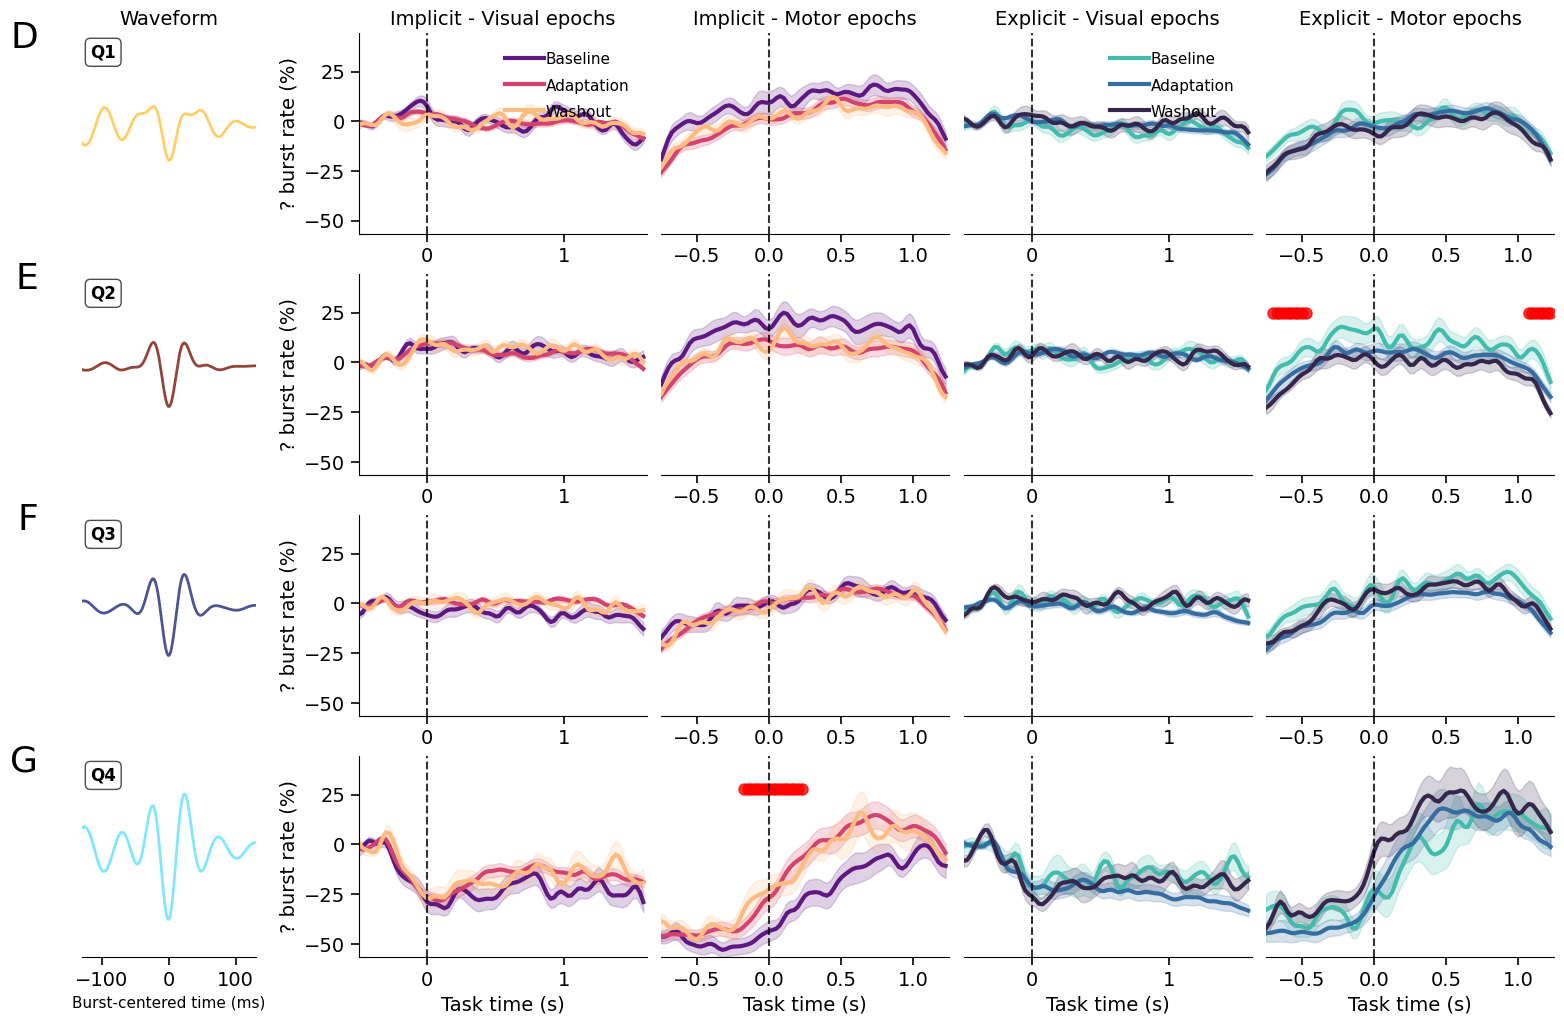

In [ ]:
from matplotlib.gridspec import GridSpec

# Load waveform data
waveform_array_file = "/home/qmoreau/explicit_implicit_bursts/data/derivatives/all_waveforms.npy"
waveform_array = np.load(waveform_array_file)

burst_feature = pd.read_csv("/home/qmoreau/explicit_implicit_bursts/data/derivatives/burst_features.csv")

waveform_time = np.linspace(-.13, .13, num=156)

# Compute waveforms for PC_7 quartiles
prct = np.linspace(0, 100, num=5)
prct_ranges = list(zip(prct[:-1], prct[1:]))
pc_key = "PC_8"
wvfrms_pc7 = []

for low, hi in prct_ranges:
    low_perc = np.percentile(burst_feature[pc_key], low)
    hi_perc = np.percentile(burst_feature[pc_key], hi)
    wvf_ixs = burst_feature.loc[
        (burst_feature[pc_key] >= low_perc) &
        (burst_feature[pc_key] <= hi_perc)
    ].index
    MWF = np.mean(waveform_array[wvf_ixs, :], axis=0)
    wvfrms_pc7.append(MWF)

# Compute y-limits for waveforms
all_wvf_data = np.array([wvf * 1e14 for wvf in wvfrms_pc7]).flatten()
wvf_ymin = np.min(all_wvf_data)
wvf_ymax = np.max(all_wvf_data)
wvf_yrange = wvf_ymax - wvf_ymin
wvf_ylims = (wvf_ymin - 0.3 * wvf_yrange, wvf_ymax + 0.3 * wvf_yrange)

# Your existing setup
phases = ['baseline', 'adaptation', 'washout']
plot_lims = {'vis': (-0.5, 1.6), 'mot': (-0.75, 1.25)}
colors0 = sns.color_palette("magma", n_colors=6)
colors1 = sns.color_palette("mako_r", n_colors=10)
colors_implicit = [colors0[1], colors0[3], colors0[5]]
colors_explicit = [colors1[2], colors1[5], colors1[8]]

for pc in ['PC_8']:
    # === Compute ylims from ALL quartiles ===
    all_means, all_sems = [], []
    for q in range(n_q):
        for epoch in ['vis', 'mot']:
            for group in ['Implicit', 'Explicit']:
                for phase in phases:
                    data = burst_data[pc][epoch][phase][q][group]
                    mean_curve = np.nanmean(data, axis=0)
                    sem_curve = sem(data, axis=0, nan_policy='omit')
                    all_means.extend(mean_curve)
                    all_sems.extend(sem_curve)
    all_means = np.array(all_means)
    all_sems = np.array(all_sems)
    range_margin = 0.05 * (np.max(all_means + all_sems) - np.min(all_means - all_sems))
    ylims = (
        np.min(all_means - all_sems),
        np.max(all_means + all_sems) + range_margin
    )
    
    # === Create figure with nested GridSpec ===
    fig = plt.figure(figsize=(19, 12))
    
    # Main GridSpec: 2 sections (waveform | burst rates) - REDUCED WHITESPACE
    gs_main = GridSpec(1, 2, figure=fig, width_ratios=[0.7, 4.8], wspace=0.15)
    
    # Left section: waveform column
    gs_left = gs_main[0, 0].subgridspec(n_q, 1, hspace=0.2)
    
    # Right section: 4 burst rate columns with tight spacing
    gs_right = gs_main[0, 1].subgridspec(n_q, 4, hspace=0.2, wspace=0.05)
    
    # Create axes array
    axes = []
    for q in range(n_q):
        row_axes = []
        # Waveform
        ax_wvf = fig.add_subplot(gs_left[q, 0])
        row_axes.append(ax_wvf)
        
        # Burst rate columns
        for col in range(4):
            ax = fig.add_subplot(gs_right[q, col])
            row_axes.append(ax)
        
        axes.append(row_axes)
    
    axes = np.array(axes)
    
    for q in range(n_q):
        # === COLUMN 0: Waveform ===
        ax_wvf = axes[q, 0]
        
        # Plot waveform for this quartile with managua colormap
        try:
            wvf_color = plt.cm.managua(q / (n_q - 1))
        except AttributeError:
            # Fallback if managua is not available
            import cmcrameri.cm as cmc
            wvf_color = cmc.managua(q / (n_q - 1))
        
        # Plot with time in milliseconds
        ax_wvf.plot(waveform_time * 1000, wvfrms_pc7[q] * 1e14, 
                    c=wvf_color, linewidth=2)
        
        # Style the waveform plot - removed horizontal and vertical lines
        ax_wvf.set_xlim(waveform_time[0] * 1000, waveform_time[-1] * 1000)
        ax_wvf.set_ylim(wvf_ylims)  # Set consistent y-limits across all waveform plots
        
        # Remove grid
        ax_wvf.grid(False)
        
        # Remove all y-axis elements
        ax_wvf.set_yticks([])
        ax_wvf.set_ylabel("")
        ax_wvf.spines['left'].set_visible(False)
        ax_wvf.spines['right'].set_visible(False)
        ax_wvf.spines['top'].set_visible(False)  # Remove top spine
        ax_wvf.tick_params(left=False, right=False)
        
        # Only show x-axis on bottom row with updated label
        if q == n_q - 1:
            ax_wvf.set_xlabel("Burst-centered time (ms)", fontsize=11)
            ax_wvf.spines['bottom'].set_visible(True)
        else:
            ax_wvf.set_xticklabels([])
            ax_wvf.set_xlabel("")
            ax_wvf.spines['bottom'].set_visible(False)
            ax_wvf.tick_params(bottom=False)
        
        if q == 0:
            ax_wvf.set_title('Waveform', fontsize=14)
        
        # Add quartile label
        quartile_label = f'Q{q+1}'
        ax_wvf.text(0.05, 0.95, quartile_label, 
                    transform=ax_wvf.transAxes,
                    fontsize=12, fontweight='bold',
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        # === COLUMNS 1-4: Burst Rate Plots ===
        for col_idx, (group, epoch) in enumerate([('Implicit', 'vis'), ('Implicit', 'mot'), 
                                                    ('Explicit', 'vis'), ('Explicit', 'mot')]):
            ax = axes[q, col_idx + 1]  # Shift by 1 for waveform column
            
            # Prepare data for all phases
            data = [
                burst_data[pc][epoch]['baseline'][q][group],
                burst_data[pc][epoch]['adaptation'][q][group],
                burst_data[pc][epoch]['washout'][q][group]
            ]
            color_set = colors_implicit if group == 'Implicit' else colors_explicit
            
            # Plot with updated labels
            xlabel = "Task time (s)" if q == n_q - 1 else ""
            ylabel = "? burst rate (%)" if col_idx == 0 else ""
            title = ""
            
            plot_and_cluster_data_blocktype_within_group(
                ax, time_plots[pc][epoch], data,
                color_set, title, xlabel, ylabel,
                verbose=False
            )
            
            ax.set_xlim(*plot_lims[epoch])
            ax.set_ylim(ylims)
            ax.axvline(0, linestyle='--', color='black', alpha=0.8)
            
            # Add column titles on first row
            if q == 0:
                epoch_name = "Visual" if epoch == 'vis' else "Motor"
                ax.set_title(f'{group} - {epoch_name} epochs', fontsize=14)
            
            # Remove y-axis labels and ticks for right columns
            if col_idx > 0:
                ax.set_ylabel("")
                ax.set_yticklabels([])
                # Remove left spine for non-leftmost columns
                ax.spines['left'].set_visible(False)
                ax.tick_params(left=False)
            
            # Handle legends
            legend = ax.get_legend()
            if legend is not None:
                if (q == 0 and col_idx == 0) or (q == 0 and col_idx == 2):
                    # Keep and modify these legends
                    legend.set_loc('upper right')
                    for text in legend.get_texts():
                        text.set_fontsize(11)
                else:
                    # Remove all other legends
                    legend.remove()
        
        # Add panel letter (one per quartile) on waveform subplot
        letter = string.ascii_uppercase[q + 3]
        add_subplot_label(axes[q, 0], letter, x=-0.25, y=1.06)
    
    plt.savefig(f'./figures/{pc}_all_quartiles_with_waveforms.pdf', 
                format='pdf', bbox_inches='tight', dpi=600)
    plt.show()

In [ ]:
# cohcats = ['zero', 'low', 'med', 'high']
# plot_lims = {'vis': (-0.5, 1.6), 'mot': (-0.75, 1.25)}
# durations = {k: plot_lims[k][1] - plot_lims[k][0] for k in ['vis', 'mot']}
# total_width = durations['vis'] + durations['mot']
# width_ratios = [durations['vis'] / total_width, durations['mot'] / total_width]

# for pc in ['PC_7','PC_8','PC_9','PC_10']:#pcs:
#     for q in range(n_q):
#         # === Compute ylims for this quartile ===
#         q_means, q_sems = [], []
#         for epoch in ['vis', 'mot']:
#             for group in ['Implicit', 'Explicit']:
#                 for coh in cohcats:
#                     data = coh_burst_data[pc][epoch][coh][q][group]
#                     mean_curve = np.nanmean(data, axis=0)
#                     sem_curve = sem(data, axis=0, nan_policy='omit')
#                     q_means.extend(mean_curve)
#                     q_sems.extend(sem_curve)

#         q_means = np.array(q_means)
#         q_sems = np.array(q_sems)
#         range_margin = 0.05 * (np.max(q_means + q_sems) - np.min(q_means - q_sems))
#         ylims = (
#             np.min(q_means - q_sems),
#             np.max(q_means + q_sems) + range_margin
#         )

#         # === Plotting ===
#         fig = plt.figure(figsize=(10, 8))
#         gs = fig.add_gridspec(2, 2, width_ratios=width_ratios)

#         for i, group in enumerate(['Implicit', 'Explicit']):
#             for j, epoch in enumerate(['vis', 'mot']):
#                 ax = fig.add_subplot(gs[i, j])
#                 data = [
#                     coh_burst_data[pc][epoch]['zero'][q][group],
#                     coh_burst_data[pc][epoch]['low'][q][group],
#                     coh_burst_data[pc][epoch]['med'][q][group],
#                     coh_burst_data[pc][epoch]['high'][q][group]
#                 ]
#                 xlabel = "Time (s)" if i == 1 else ""
#                 ylabel = "Burst Rate" if j == 0 else ""
#                 title = f"{group} - Coherence (PC {pc.split('_')[1]}, Q{q+1})" if j == 0 else ""
#                 colors = colors4 if group == 'Implicit' else colors5

#                 plot_and_cluster_data_coh(
#                     ax, time_plots[pc][epoch], data,
#                     colors, title, xlabel, ylabel,
#                     verbose=False
#                 )
#                 ax.set_xlim(*plot_lims[epoch])
#                 ax.set_ylim(ylims)

#         for ax in fig.axes:
#             ax.axvline(0, linestyle='--', color='black', alpha=0.8)

#         plt.tight_layout()
#         # plt.savefig(f'./figures/{pc}_q{q+1}_coherence_effects.pdf', format='pdf', bbox_inches='tight', dpi=600)
#         # plt.close()


/tmp/ipykernel_22121/2734624954.py:110: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(


Significant clusters found!


/tmp/ipykernel_22121/2734624954.py:110: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(


Significant clusters found!
Significant clusters found!


/tmp/ipykernel_22121/2734624954.py:110: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
/tmp/ipykernel_22121/2734624954.py:110: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(


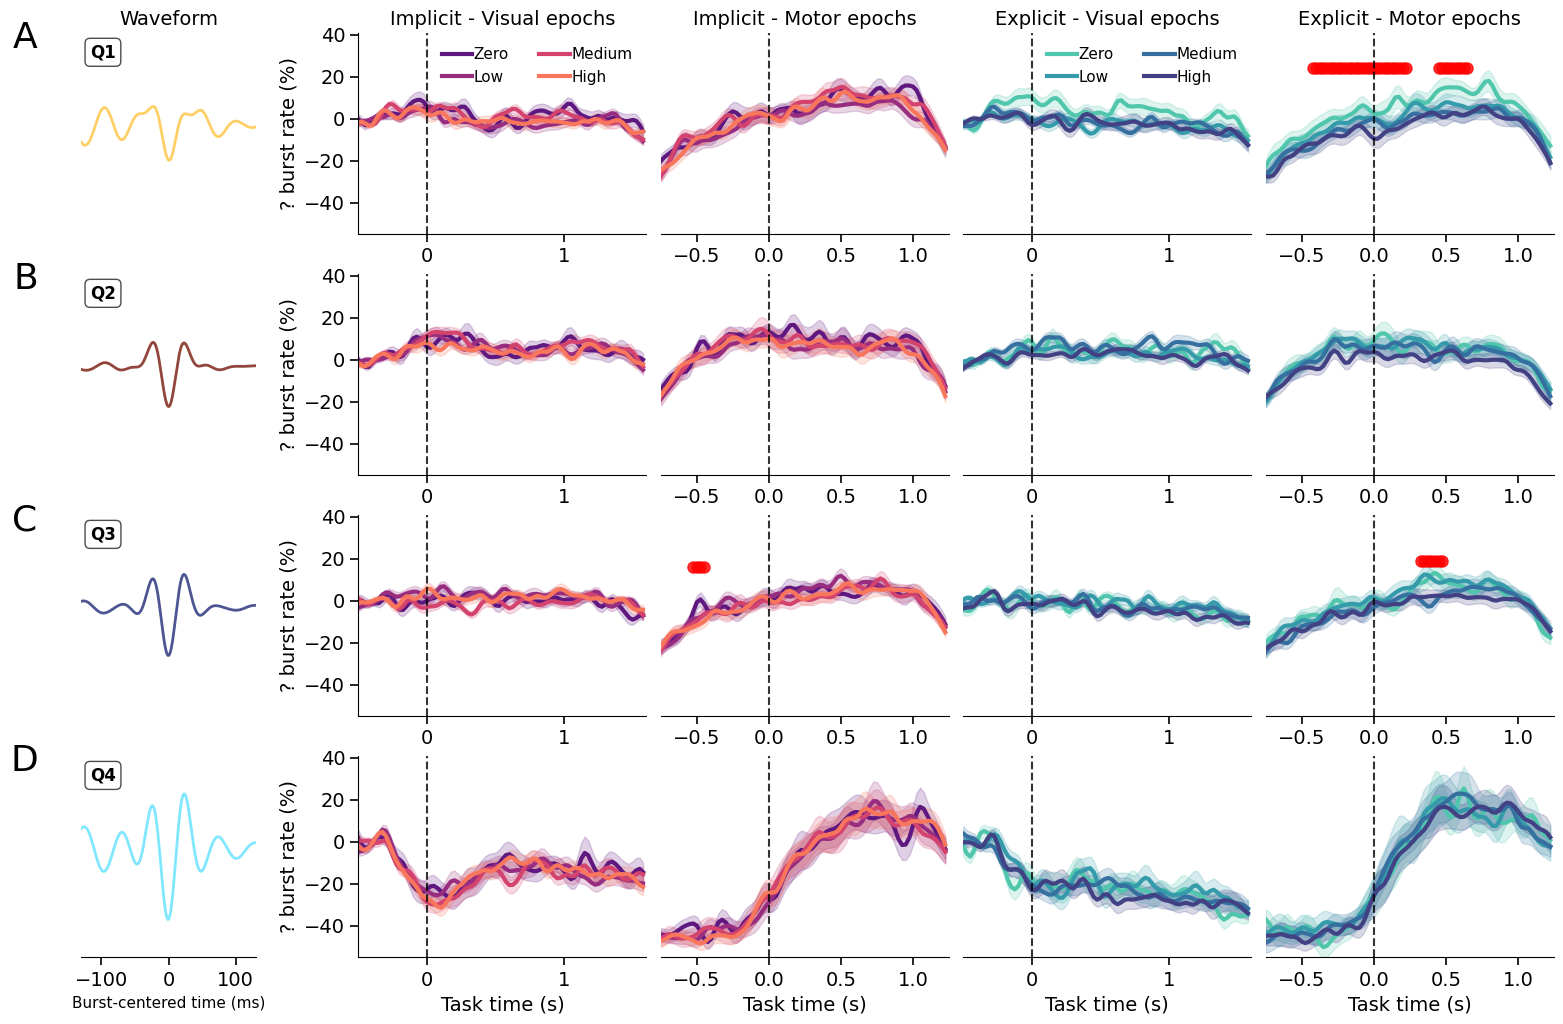

In [ ]:
from matplotlib.gridspec import GridSpec

# Load waveform data
waveform_array_file = "/home/qmoreau/explicit_implicit_bursts/data/derivatives/all_waveforms.npy"
waveform_array = np.load(waveform_array_file)

burst_feature = pd.read_csv("/home/qmoreau/explicit_implicit_bursts/data/derivatives/burst_features.csv")

waveform_time = np.linspace(-.13, .13, num=156)

# Compute waveforms for PC_7 quartiles
prct = np.linspace(0, 100, num=5)
prct_ranges = list(zip(prct[:-1], prct[1:]))
pc_key = "PC_8"
wvfrms_pc7 = []

for low, hi in prct_ranges:
    low_perc = np.percentile(burst_feature[pc_key], low)
    hi_perc = np.percentile(burst_feature[pc_key], hi)
    wvf_ixs = burst_feature.loc[
        (burst_feature[pc_key] >= low_perc) &
        (burst_feature[pc_key] <= hi_perc)
    ].index
    MWF = np.mean(waveform_array[wvf_ixs, :], axis=0)
    wvfrms_pc7.append(MWF)

# Compute y-limits for waveforms
all_wvf_data = np.array([wvf * 1e14 for wvf in wvfrms_pc7]).flatten()
wvf_ymin = np.min(all_wvf_data)
wvf_ymax = np.max(all_wvf_data)
wvf_yrange = wvf_ymax - wvf_ymin
wvf_ylims = (wvf_ymin - 0.3 * wvf_yrange, wvf_ymax + 0.3 * wvf_yrange)

# Setup for coherence analysis
cohcats = ['zero', 'low', 'med', 'high']
plot_lims = {'vis': (-0.5, 1.6), 'mot': (-0.75, 1.25)}

# Define colors for coherence levels (4 levels) - FIXED
colors4 = sns.color_palette("magma", n_colors=6)[1:5]  # 4 colors for implicit
colors5 = sns.color_palette("mako_r", n_colors=12)[2:10:2]  # 4 colors for explicit (indices 2,4,6,8)

for pc in ['PC_8']:
    # === Compute ylims from ALL quartiles and coherence levels ===
    all_means, all_sems = [], []
    for q in range(n_q):
        for epoch in ['vis', 'mot']:
            for group in ['Implicit', 'Explicit']:
                for coh in cohcats:
                    data = coh_burst_data[pc][epoch][coh][q][group]
                    mean_curve = np.nanmean(data, axis=0)
                    sem_curve = sem(data, axis=0, nan_policy='omit')
                    all_means.extend(mean_curve)
                    all_sems.extend(sem_curve)
    all_means = np.array(all_means)
    all_sems = np.array(all_sems)
    range_margin = 0.05 * (np.max(all_means + all_sems) - np.min(all_means - all_sems))
    ylims = (
        np.min(all_means - all_sems),
        np.max(all_means + all_sems) + range_margin
    )
    
    # === Create figure with nested GridSpec ===
    fig = plt.figure(figsize=(19, 12))
    
    # Main GridSpec: 2 sections (waveform | burst rates) - REDUCED WHITESPACE
    gs_main = GridSpec(1, 2, figure=fig, width_ratios=[0.7, 4.8], wspace=0.15)
    
    # Left section: waveform column
    gs_left = gs_main[0, 0].subgridspec(n_q, 1, hspace=0.2)
    
    # Right section: 4 burst rate columns with tight spacing
    gs_right = gs_main[0, 1].subgridspec(n_q, 4, hspace=0.2, wspace=0.05)
    
    # Create axes array
    axes = []
    for q in range(n_q):
        row_axes = []
        # Waveform
        ax_wvf = fig.add_subplot(gs_left[q, 0])
        row_axes.append(ax_wvf)
        
        # Burst rate columns
        for col in range(4):
            ax = fig.add_subplot(gs_right[q, col])
            row_axes.append(ax)
        
        axes.append(row_axes)
    
    axes = np.array(axes)
    
    for q in range(n_q):
        # === COLUMN 0: Waveform ===
        ax_wvf = axes[q, 0]
        
        # Plot waveform for this quartile with managua colormap
        try:
            wvf_color = plt.cm.managua(q / (n_q - 1))
        except AttributeError:
            # Fallback if managua is not available
            import cmcrameri.cm as cmc
            wvf_color = cmc.managua(q / (n_q - 1))
        
        # Plot with time in milliseconds
        ax_wvf.plot(waveform_time * 1000, wvfrms_pc7[q] * 1e14, 
                    c=wvf_color, linewidth=2)
        
        # Style the waveform plot - removed horizontal and vertical lines
        ax_wvf.set_xlim(waveform_time[0] * 1000, waveform_time[-1] * 1000)
        ax_wvf.set_ylim(wvf_ylims)  # Set consistent y-limits across all waveform plots
        
        # Remove grid
        ax_wvf.grid(False)
        
        # Remove all y-axis elements
        ax_wvf.set_yticks([])
        ax_wvf.set_ylabel("")
        ax_wvf.spines['left'].set_visible(False)
        ax_wvf.spines['right'].set_visible(False)
        ax_wvf.spines['top'].set_visible(False)  # Remove top spine
        ax_wvf.tick_params(left=False, right=False)
        
        # Only show x-axis on bottom row with updated label
        if q == n_q - 1:
            ax_wvf.set_xlabel("Burst-centered time (ms)", fontsize=11)
            ax_wvf.spines['bottom'].set_visible(True)
        else:
            ax_wvf.set_xticklabels([])
            ax_wvf.set_xlabel("")
            ax_wvf.spines['bottom'].set_visible(False)
            ax_wvf.tick_params(bottom=False)
        
        if q == 0:
            ax_wvf.set_title('Waveform', fontsize=14)
        
        # Add quartile label
        quartile_label = f'Q{q+1}'
        ax_wvf.text(0.05, 0.95, quartile_label, 
                    transform=ax_wvf.transAxes,
                    fontsize=12, fontweight='bold',
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        # === COLUMNS 1-4: Burst Rate Plots ===
        for col_idx, (group, epoch) in enumerate([('Implicit', 'vis'), ('Implicit', 'mot'), 
                                                    ('Explicit', 'vis'), ('Explicit', 'mot')]):
            ax = axes[q, col_idx + 1]  # Shift by 1 for waveform column
            
            # Prepare data for all coherence levels
            data = [
                coh_burst_data[pc][epoch]['zero'][q][group],
                coh_burst_data[pc][epoch]['low'][q][group],
                coh_burst_data[pc][epoch]['med'][q][group],
                coh_burst_data[pc][epoch]['high'][q][group]
            ]
            color_set = colors4 if group == 'Implicit' else colors5
            
            # Plot with updated labels
            xlabel = "Task time (s)" if q == n_q - 1 else ""
            ylabel = "? burst rate (%)" if col_idx == 0 else ""
            title = ""
            
            plot_and_cluster_data_coh(
                ax, time_plots[pc][epoch], data,
                color_set, title, xlabel, ylabel,
                verbose=False
            )
            
            ax.set_xlim(*plot_lims[epoch])
            ax.set_ylim(ylims)
            ax.axvline(0, linestyle='--', color='black', alpha=0.8)
            
            # Add column titles on first row
            if q == 0:
                epoch_name = "Visual" if epoch == 'vis' else "Motor"
                ax.set_title(f'{group} - {epoch_name} epochs', fontsize=14)
            
            # Remove y-axis labels and ticks for right columns
            if col_idx > 0:
                ax.set_ylabel("")
                ax.set_yticklabels([])
                # Remove left spine for non-leftmost columns
                ax.spines['left'].set_visible(False)
                ax.tick_params(left=False)
            
            # Handle legends with 2 columns
            legend = ax.get_legend()
            if legend is not None:
                if (q == 0 and col_idx == 0) or (q == 0 and col_idx == 2):
                    # Keep and modify these legends - set to 2 columns
                    handles, labels = ax.get_legend_handles_labels()
                    ax.legend(handles, labels, loc='upper right', fontsize=11, ncol=2)
                else:
                    # Remove all other legends
                    legend.remove()
        
        # Add panel letter (one per quartile) on waveform subplot
        letter = string.ascii_uppercase[q]
        add_subplot_label(axes[q, 0], letter, x=-0.25, y=1.06)
    
    
    plt.savefig(f'./figures/{pc}_all_quartiles_coherence_with_waveforms.pdf', 
                format='pdf', bbox_inches='tight', dpi=600)
    plt.show()